# Thompson Sampling MDP — Replay Scheme Comparison

Same six conditions as the bandit notebook, applied to a noisy gridworld:
no replay · uniform · TD-error · uncertainty · VPI · EVB.

In [1]:
import sys
sys.path.insert(0, ".")

import numpy as np
import matplotlib.pyplot as plt

from environments import NoisyGridworld
from bayesian_qlearning import NormalGamma
from replay_buffer import Experience

np.random.seed(42)
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

## Environment

In [23]:
# Set WORLD = "easy"  ->  4x4, no walls, low noise
#     WORLD = "hard"  ->  5x5, walls,    higher noise
WORLD = "hard"

CONFIGS = {
    "easy": dict(
        height=4, width=4,
        start=(0, 0),
        goals={(3, 3): 1.0},
        walls=set(),
        slip_prob=0.1,
        reward_noise=0.1,
        step_cost=0.01,
        gamma=0.99,
        n_steps=50_000,
        n_init_steps=4000,
        window=100,
        description="4x4, no walls, slip=0.1, noise=0.1",
    ),
    "hard": dict(
        height=5, width=5,
        start=(0, 0),
        goals={(4, 4): 1.0},
        walls={(1, 1), (1, 2), (2, 2), (3, 1)},
        slip_prob=0.2,
        reward_noise=0.3,
        step_cost=0.01,
        gamma=0.99,
        n_steps=10_000,
        n_init_steps=400,
        window=200,
        description="5x5, walls, slip=0.2, noise=0.3",
    ),
}

cfg          = CONFIGS[WORLD]
GAMMA        = cfg["gamma"]
N_STEPS      = cfg["n_steps"]
N_INIT_STEPS = cfg["n_init_steps"]
WINDOW       = cfg["window"]

env = NoisyGridworld(
    height      = cfg["height"],
    width       = cfg["width"],
    start       = cfg["start"],
    goals       = cfg["goals"],
    walls       = cfg["walls"],
    slip_prob   = cfg["slip_prob"],
    reward_noise= cfg["reward_noise"],
    step_cost   = cfg["step_cost"],
)
print(f"Config : {WORLD!r} -- {cfg['description']}")
print(f"states={env.n_states}  actions={env.n_actions}  "
      f"N_STEPS={N_STEPS}  N_INIT_STEPS={N_INIT_STEPS}  WINDOW={WINDOW}")
print()
print(env.render())

Config : 'hard' -- 5x5, walls, slip=0.2, noise=0.3
states=25  actions=4  N_STEPS=10000  N_INIT_STEPS=400  WINDOW=200

A . . . .
. # # . .
. . # . .
. # . . .
. . . . G


## Agent

In [24]:
class ThompsonSamplingMDP:
    """Thompson sampling with Normal-Gamma posteriors for multi-state MDPs.

    Action selection: sample Q(s,a) ~ t(df, mu, scale) for each action, take argmax.
    Q-update: moment-matching bootstrap — target = r + gamma * max_a' E[Q(s', a')].
    Exposes q_means / q_params so all priority functions work without modification.
    """

    def __init__(self, n_states: int, n_actions: int, gamma: float = 0.99,
                 mu0: float = 0.0, lam0: float = 1.0,
                 alpha0: float = 1.0, beta0: float = 1.0):
        self.n_states  = n_states
        self.n_actions = n_actions
        self.gamma     = gamma
        prior   = NormalGamma(mu=mu0, lam=lam0, alpha=alpha0, beta=beta0)
        self._q = [[prior] * n_actions for _ in range(n_states)]

    def select_action(self, state: int) -> int:
        return int(np.argmax([self._q[state][a].sample() for a in range(self.n_actions)]))

    def update(self, state: int, action: int, reward: float,
               next_state: int, done: bool) -> None:
        if done:
            target = reward
        else:
            target = reward + self.gamma * max(
                self._q[next_state][a].mean for a in range(self.n_actions))
        self._q[state][action] = self._q[state][action].update(target)

    def q_means(self, state: int) -> np.ndarray:
        return np.array([self._q[state][a].mean for a in range(self.n_actions)])

    def q_params(self, state: int, action: int) -> NormalGamma:
        return self._q[state][action]

## Priority functions

In [25]:
class UniformPriority:
    def __call__(self, exp: Experience) -> float:
        return 1.0


class TDErrorPriority:
    """Priority = |TD error| = |r + gamma * max_a' E[Q(s',a')] - E[Q(s,a)]|."""

    def __init__(self, agent, gamma: float):
        self.agent = agent
        self.gamma = gamma

    def __call__(self, exp: Experience) -> float:
        if exp.done or self.gamma == 0.0:
            target = exp.reward
        else:
            target = exp.reward + self.gamma * float(
                np.max(self.agent.q_means(exp.next_state)))
        return abs(target - self.agent.q_params(exp.state, exp.action).mean)


class UncertaintyPriority:
    """Priority = posterior scale of Q(s, a)."""

    def __init__(self, agent):
        self.agent = agent

    def __call__(self, exp: Experience) -> float:
        return self.agent.q_params(exp.state, exp.action).scale


class VPIPriority:
    """Priority = VPI bonus of (s, a)  (Dearden et al. 1998).

    greedy action a*:   E[max(Q_2nd - Q(s,a*), 0)]  put  at second-best mean
    non-greedy action:  E[max(Q(s,a) - Q_best, 0)]  call at best mean
    """

    def __init__(self, agent):
        self.agent = agent

    def __call__(self, exp: Experience) -> float:
        s, a   = exp.state, exp.action
        means  = self.agent.q_means(s)
        best_a = int(np.argmax(means))
        p      = self.agent.q_params(s, a)
        if a == best_a:
            competing   = np.delete(means, a)
            second_best = float(competing.max()) if len(competing) > 0 else -np.inf
            return p.expected_shortfall(second_best)
        else:
            return p.expected_improvement(float(means[best_a]))


class EVBPriority:
    """Expected Value of Backup: GAIN x NEED with NEED=1.

    GAIN = predicted increase in V(s) = max_a E[Q(s,a)] from one conjugate
    update with this experience, computed analytically without side effects.
    NEED = 1 everywhere (approximation; proper NEED is the on-policy successor
    representation, which would weight states by expected future visit count).
    """

    def __init__(self, agent, gamma: float):
        self.agent = agent
        self.gamma = gamma

    def __call__(self, exp: Experience) -> float:
        s, a, r, s_next, done = exp
        means    = self.agent.q_means(s)
        v_before = float(np.max(means))
        T = r if done else r + self.gamma * float(np.max(self.agent.q_means(s_next)))
        ng             = self.agent.q_params(s, a)
        mu_after       = (ng.lam * ng.mu + T) / (ng.lam + 1.0)
        means_after    = means.copy()
        means_after[a] = mu_after
        return max(0.0, float(np.max(means_after)) - v_before)

## Replay buffer

In [26]:
class DiscardReplayBuffer:
    """Pre-populated buffer that samples and permanently discards experiences.

    priority_fn=None  -> uniform random sampling; no re-evaluation needed.
    Otherwise priorities are re-evaluated at sample time from the current
    agent state (correct for experience-level priorities like TD-error, EVB).

    Note: UncertaintyPriority and VPIPriority depend only on (state, action),
    not on the specific reward observation.  For large gridworlds a two-stage
    (state, action)-grouped sampler (O(unique s,a pairs)) would be more
    efficient, but for small grids the O(buffer_size) cost here is negligible.
    """

    def __init__(self, priority_fn=None, alpha: float = 1.0, epsilon: float = 1e-6):
        self.priority_fn = priority_fn
        self.alpha       = alpha
        self.epsilon     = epsilon
        self._buf: list  = []

    def push(self, state: int, action: int, reward: float,
             next_state: int, done: bool) -> None:
        self._buf.append(Experience(state, action, float(reward), next_state, bool(done)))

    def sample_and_discard(self, n: int = 1) -> list:
        n = min(n, len(self._buf))
        if n == 0:
            return []
        if self.priority_fn is None:
            indices = np.random.choice(len(self._buf), size=n, replace=False)
        else:
            priorities = np.array([
                max(float(self.priority_fn(e)), 0.0) + self.epsilon
                for e in self._buf
            ]) ** self.alpha
            probs   = priorities / priorities.sum()
            indices = np.random.choice(len(self._buf), size=n, replace=False, p=probs)
        selected = [self._buf[i] for i in indices]
        for i in sorted(indices, reverse=True):
            del self._buf[i]
        return selected

    def replay_into(self, agent, n: int = 1) -> None:
        for exp in self.sample_and_discard(n):
            agent.update(exp.state, exp.action, exp.reward, exp.next_state, exp.done)

    def __len__(self) -> int:
        return len(self._buf)

    def __repr__(self) -> str:
        return f"DiscardReplayBuffer(remaining={len(self)})"

## Experiment

In [27]:
def pre_populate(buf, env, n_steps):
    """Random exploration to pre-populate the buffer. No agent updates."""
    state = env.reset()
    for _ in range(n_steps):
        action = np.random.randint(env.n_actions)
        next_state, r, done, _ = env.step(action)
        buf.push(state, action, r, next_state, done)
        state = next_state if not done else env.reset()


def run_no_replay(agent, env, n_steps):
    state = env.reset()
    rewards = np.zeros(n_steps)
    for t in range(n_steps):
        a = agent.select_action(state)
        next_state, r, done, _ = env.step(a)
        agent.update(state, a, r, next_state, done)
        rewards[t] = r
        state = next_state if not done else env.reset()
    return rewards


def run_with_fixed_replay(agent, env, n_steps, buf, replay_every, replay_n):
    """Online learning interleaved with replay from a fixed pre-populated buffer.

    New online experiences update the agent but are never added to the buffer.
    Each replayed experience is permanently discarded.
    Replay stops naturally once the buffer is exhausted.
    """
    state = env.reset()
    rewards = np.zeros(n_steps)
    for t in range(n_steps):
        a = agent.select_action(state)
        next_state, r, done, _ = env.step(a)
        agent.update(state, a, r, next_state, done)
        if (t + 1) % replay_every == 0 and len(buf) > 0:
            buf.replay_into(agent, replay_n)
        rewards[t] = r
        state = next_state if not done else env.reset()
    return rewards

In [28]:
N_SEEDS      = 10
REPLAY_EVERY = 5
REPLAY_N     = 1
# buffer exhausted after N_INIT_STEPS * REPLAY_EVERY online steps

SCHEMES = {
    "No replay":          lambda agent: None,
    "Uniform replay":     lambda agent: DiscardReplayBuffer(priority_fn=None),
    "TD-error replay":    lambda agent: DiscardReplayBuffer(TDErrorPriority(agent, GAMMA)),
    "Uncertainty replay": lambda agent: DiscardReplayBuffer(UncertaintyPriority(agent)),
    "VPI replay":         lambda agent: DiscardReplayBuffer(VPIPriority(agent)),
    "EVB replay":         lambda agent: DiscardReplayBuffer(EVBPriority(agent, GAMMA)),
}

results = {}

for scheme, make_buf in SCHEMES.items():
    all_r = []
    for seed in range(N_SEEDS):
        np.random.seed(seed)
        agent = ThompsonSamplingMDP(
            n_states=env.n_states, n_actions=env.n_actions, gamma=GAMMA)
        buf = make_buf(agent)
        if buf is not None:
            pre_populate(buf, env, N_INIT_STEPS)
        if buf is None:
            r = run_no_replay(agent, env, N_STEPS)
        else:
            r = run_with_fixed_replay(
                agent, env, N_STEPS, buf, REPLAY_EVERY, REPLAY_N)
        all_r.append(r)
    results[scheme] = np.array(all_r)  # (n_seeds, n_steps)
    mean_r = results[scheme].mean()
    cum_r  = results[scheme].sum(1).mean()
    print(f"{scheme:<22}  avg reward={mean_r:.4f}  cum. reward={cum_r:.1f}")

No replay               avg reward=0.0061  cum. reward=60.6
Uniform replay          avg reward=-0.0039  cum. reward=-39.1
TD-error replay         avg reward=0.0050  cum. reward=50.5
Uncertainty replay      avg reward=0.0102  cum. reward=101.6
VPI replay              avg reward=0.0022  cum. reward=21.6
EVB replay              avg reward=0.0098  cum. reward=97.6


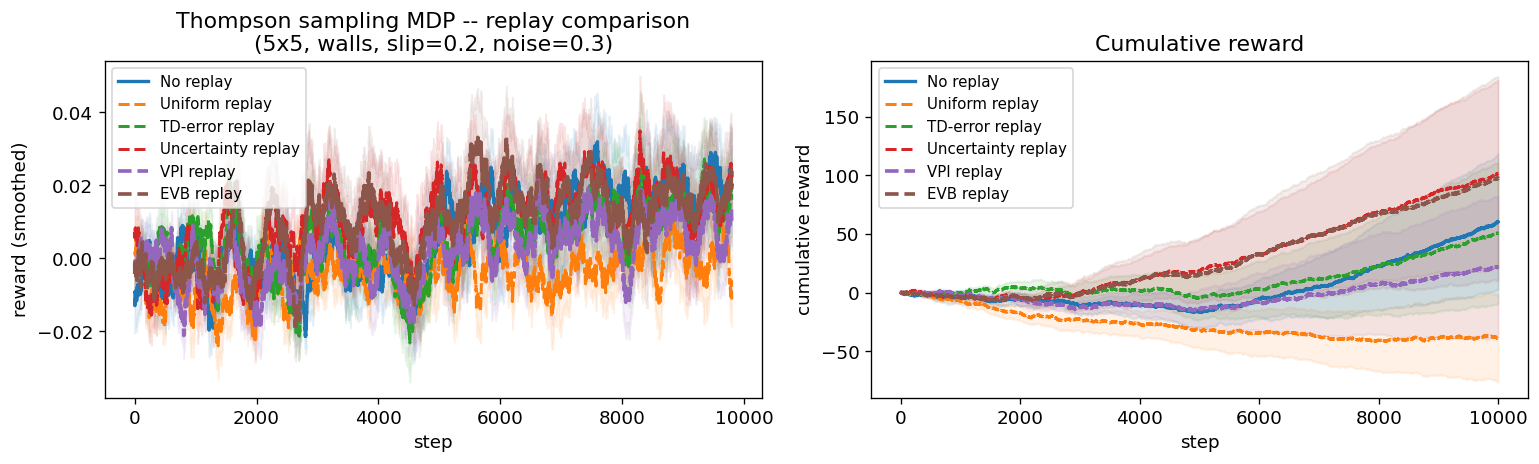

In [22]:
def smooth(x):
    return np.convolve(x, np.ones(WINDOW) / WINDOW, mode="valid")

STYLES = {
    "No replay":          ("C0", "-",  2.0),
    "Uniform replay":     ("C1", "--", 1.8),
    "TD-error replay":    ("C2", "--", 1.8),
    "Uncertainty replay": ("C3", "--", 1.8),
    "VPI replay":         ("C4", "--", 2.2),
    "EVB replay":         ("C5", "--", 2.2),
}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for scheme, data in results.items():
    color, ls, lw = STYLES[scheme]
    r_sm  = np.array([smooth(row) for row in data])
    steps = np.arange(r_sm.shape[1])
    mu    = r_sm.mean(0)
    sem   = r_sm.std(0) / np.sqrt(N_SEEDS)
    axes[0].plot(steps, mu, label=scheme, color=color, ls=ls, lw=lw)
    axes[0].fill_between(steps, mu - sem, mu + sem, color=color, alpha=0.10)

    cum     = data.cumsum(1)
    mu_cum  = cum.mean(0)
    sem_cum = cum.std(0) / np.sqrt(N_SEEDS)
    axes[1].plot(mu_cum, label=scheme, color=color, ls=ls, lw=lw)
    axes[1].fill_between(
        np.arange(N_STEPS), mu_cum - sem_cum, mu_cum + sem_cum, color=color, alpha=0.10)

axes[0].set(xlabel="step", ylabel="reward (smoothed)",
            title=f"Thompson sampling MDP -- replay comparison\n({cfg['description']})")
axes[1].set(xlabel="step", ylabel="cumulative reward", title="Cumulative reward")
for ax in axes:
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()